In [1]:
# === Initialisation : chargement du dataset ===
import os
import pandas as pd

data_dir = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "data", "COVID-19_Radiography_Dataset")

data = []
for category in os.listdir(data_dir):
    folder_images = os.path.join(data_dir, category, "images")
    if os.path.isdir(folder_images):
        for file in os.listdir(folder_images):
            if file.endswith(".png") or file.endswith(".jpg"):
                data.append({
                    "image_path": os.path.join(folder_images, file),
                    "label": category
                })

df_images = pd.DataFrame(data)
print(f"Dataset charge : {len(df_images)} images")
print(df_images['label'].value_counts())

Dataset charge : 21165 images
label
Normal             10192
Lung_Opacity        6012
COVID               3616
Viral Pneumonia     1345
Name: count, dtype: int64


In [2]:
# === Initialisation : preprocessing des images ===
import numpy as np
from PIL import Image

TARGET_SIZE = (256, 256)

def preprocess_image(path):
    img = Image.open(path).convert('L')
    img = img.resize(TARGET_SIZE)
    img_array = np.array(img, dtype=np.float32) / 255.0
    return img_array

print("Preprocessing des images...")
X_list = [preprocess_image(p) for p in df_images['image_path']]
print(f"X_list : {len(X_list)} images preprocessees")

Preprocessing des images...
X_list : 21165 images preprocessees


In [3]:
# === Initialisation : preparation des donnees pour modelisation ===
import numpy as np
import cv2
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

TARGET_SIZE_SMALL = (64, 64)
X_small = np.array([cv2.resize(img, TARGET_SIZE_SMALL) for img in X_list], dtype=np.float32) / 255.0
X_flat = X_small.reshape(X_small.shape[0], -1)

le = LabelEncoder()
y = le.fit_transform(df_images['label'].values)

X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Classes: {list(le.classes_)}")

Train: 16932, Test: 4233
Classes: ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']


In [4]:
# === Initialisation : dossier de sauvegarde ===
import os
save_dir = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "reports")
os.makedirs(save_dir, exist_ok=True)

=== STEP 3 OPTIMISÉ ===
Classes : ['COVID' 'Lung_Opacity' 'Normal' 'Viral Pneumonia']
Class Weights : {0: np.float64(1.4632881637168142), 1: np.float64(0.8801147704590818), 2: np.float64(0.5191571821036107), 3: np.float64(3.934014869888476)}


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ features                        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,596 (432.02 KB)

 Trainable params: 110,148 (430.27 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/40
530/530 ━━━━━━━━━━━━━━━━━━━━ 144s 265ms/step - accuracy: 0.5148 - loss: 1.0824 - val_accuracy: 0.1708 - val_loss: 1.4500
Epoch 2/40
530/530 ━━━━━━━━━━━━━━━━━━━━ 121s 228ms/step - accuracy: 0.6101 - loss: 0.8400 - val_accuracy: 0.2842 - val_loss: 8.7491
Epoch 3/40
530/530 ━━━━━━━━━━━━━━━━━━━━ 124s 235ms/step - accuracy: 0.6481 - loss: 0.7486 - val_accuracy: 0.2842 - val_loss: 11.6301
Epoch 4/40
530/530 ━━━━━━━━━━━━━━━━━━━━ 168s 318ms/step - accuracy: 0.6747 - loss: 0.6865 - val_accuracy: 0.2842 - val_loss: 36.9738
Epoch 5/40
530/530 ━━━━━━━━━━━━━━━━━━━━ 172s 324ms/step - accuracy: 0.6983 - loss: 0.6383 - val_accuracy: 0.1710 - val_loss: 4.6749
Epoch 6/40
530/530 ━━━━━━━━━━━━━━━━━━━━ 175s 330ms/step - accuracy: 0.7226 - loss: 0.5916 - val_accuracy: 0.2842 - val_loss: 12.3946
Epoch 7/40
530/530 ━━━━━━━━━━━━━━━━━━━━ 151s 284ms/step - accuracy: 0.7386 - loss: 0.5553 - val_accuracy: 0.4815 - val_loss: 31.5205
Epoch 8/40
530/530 ━━━━━━━━━━━━━━━━━━━━ 144s 272ms/step - accuracy: 0.75

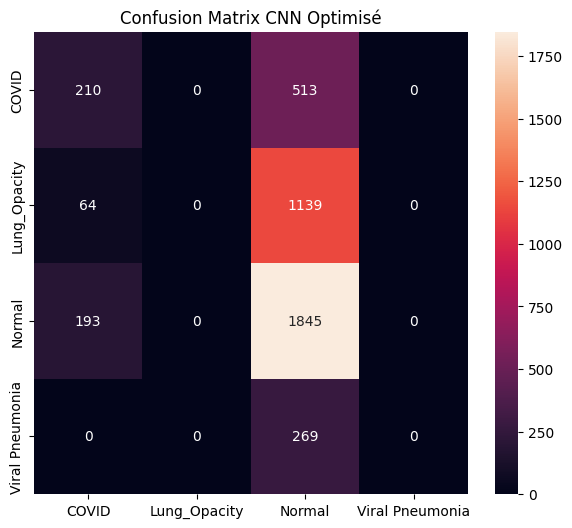

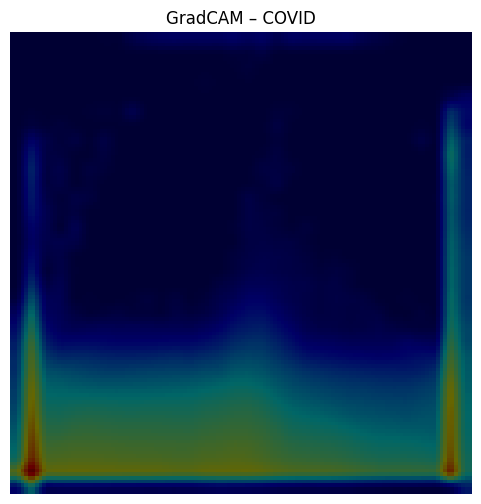

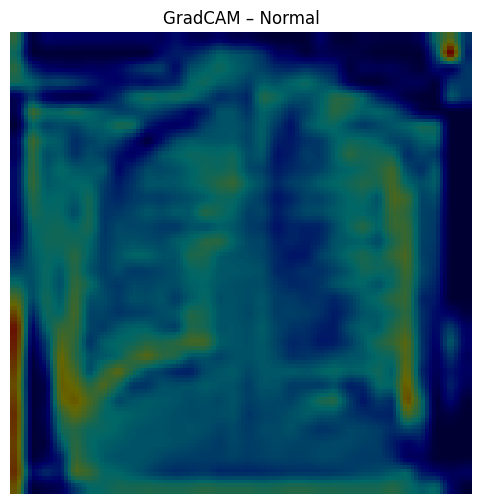

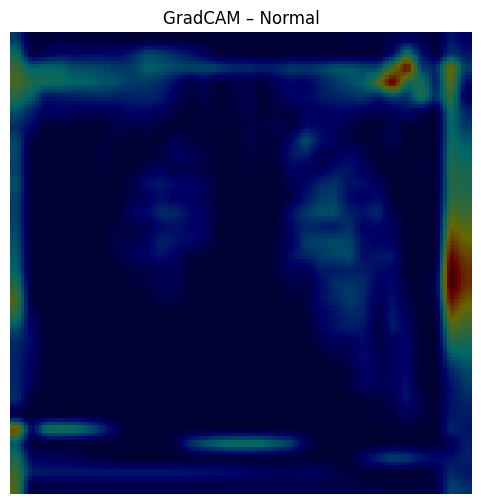

530/530 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step
133/133 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step

=== Boosting Report ===
                 precision    recall  f1-score   support

          COVID       0.90      0.84      0.87       723
   Lung_Opacity       0.79      0.76      0.78      1203
         Normal       0.84      0.87      0.86      2038
Viral Pneumonia       0.90      0.90      0.90       269

       accuracy                           0.84      4233
      macro avg       0.86      0.84      0.85      4233
   weighted avg       0.84      0.84      0.84      4233



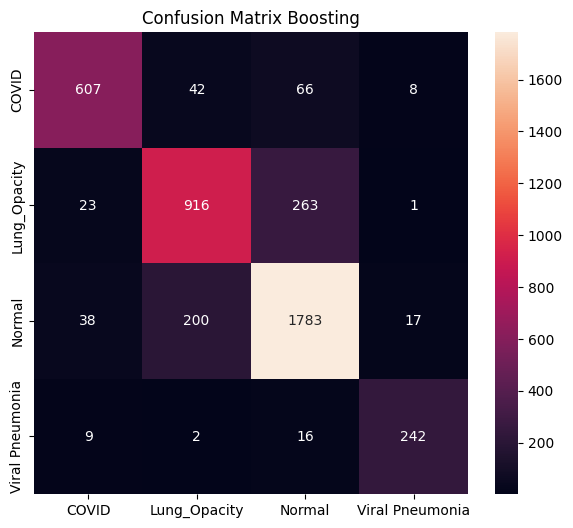


=== FIN STEP 3 OPTIMISÉ ===


In [5]:
# =============================================================
# STEP 3 – Deep Learning Optimisé + Boosting + GradCAM
# =============================================================

import os
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.layers import (Conv2D, MaxPooling2D,
                                     GlobalAveragePooling2D,
                                     Dense, Dropout,
                                     BatchNormalization, Input)
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_class_weight

# ------------------------------------------------
print("=== STEP 3 OPTIMISÉ ===")

save_dir = r"../reports"
os.makedirs(save_dir, exist_ok=True)

# ------------------------------------------------
# 1️⃣ Labels
# ------------------------------------------------
le = LabelEncoder()
y_encoded = le.fit_transform(df_images['label'].values)
n_classes = len(le.classes_)

print("Classes :", le.classes_)

# ------------------------------------------------
# 2️⃣ Images
# ------------------------------------------------
X_cnn = np.array([cv2.resize(img, (128,128)) for img in X_list],
                 dtype=np.float32) / 255.0

if X_cnn.ndim == 3:
    X_cnn = X_cnn[..., np.newaxis]

y_cnn = to_categorical(y_encoded, num_classes=n_classes)

# ------------------------------------------------
# 3️⃣ Split
# ------------------------------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X_cnn, y_cnn,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# ------------------------------------------------
# 4️⃣ Class Weights 
# ------------------------------------------------
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_encoded),
    y=y_encoded
)

class_weights_dict = dict(enumerate(class_weights))
print("Class Weights :", class_weights_dict)

# ------------------------------------------------
# 5️⃣ CNN AMÉLIORÉ
# ------------------------------------------------
inputs = Input(shape=X_train.shape[1:])

x = Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)

x = Conv2D(64, (3,3), padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)

x = Conv2D(128, (3,3), padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)

x = GlobalAveragePooling2D(name='features')(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

outputs = Dense(n_classes, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ------------------------------------------------
# 6️⃣ Entraînement
# ------------------------------------------------
checkpoint = ModelCheckpoint(
    os.path.join(save_dir, "best_model.keras"),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=6,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    callbacks=[checkpoint, early_stop],
    class_weight=class_weights_dict
)

# ------------------------------------------------
# 7️⃣ Évaluation
# ------------------------------------------------
y_pred_prob = model.predict(X_val)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_val, axis=1)

print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred,
                            target_names=le.classes_,
                            zero_division=0))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Confusion Matrix CNN Optimisé")
plt.savefig(os.path.join(save_dir, "confusion_cnn.png"))
plt.show()

# ------------------------------------------------
# 8️⃣ Grad-CAM 
# ------------------------------------------------
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy()

# dernière couche conv
last_conv_layer_name = [l.name for l in model.layers
                        if isinstance(l, Conv2D)][-1]

indices = [5, 15, 30]

for i, idx in enumerate(indices):

    img = X_val[idx][np.newaxis, ...]
    heatmap = make_gradcam_heatmap(img, model, last_conv_layer_name)

    img_orig = (X_val[idx] * 255).astype(np.uint8).squeeze()

    heatmap = cv2.resize(heatmap,
                         (img_orig.shape[1], img_orig.shape[0]))

    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed = cv2.addWeighted(
        cv2.cvtColor(img_orig, cv2.COLOR_GRAY2BGR),
        0.6,
        heatmap_color,
        0.4,
        0
    )

    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
    plt.title(f"GradCAM – {le.classes_[y_pred[idx]]}")
    plt.axis('off')

    plt.savefig(os.path.join(save_dir, f"gradcam_{i}.png"))
    plt.show()

# ------------------------------------------------
# 9️⃣ Boosting sur features CNN
# ------------------------------------------------
feature_model = Model(
    inputs=model.input,
    outputs=model.get_layer('features').output
)

X_train_feat = feature_model.predict(X_train)
X_val_feat = feature_model.predict(X_val)

gb = GradientBoostingClassifier(
    n_estimators=300,
    random_state=42
)

gb.fit(X_train_feat, np.argmax(y_train, axis=1))
y_gb = gb.predict(X_val_feat)

print("\n=== Boosting Report ===")
print(classification_report(np.argmax(y_val, axis=1),
                            y_gb,
                            target_names=le.classes_,
                            zero_division=0))

cm_gb = confusion_matrix(np.argmax(y_val, axis=1), y_gb)

plt.figure(figsize=(7,6))
sns.heatmap(cm_gb, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Confusion Matrix Boosting")
plt.savefig(os.path.join(save_dir, "confusion_boosting.png"))
plt.show()

print("\n=== FIN STEP 3 OPTIMISÉ ===")


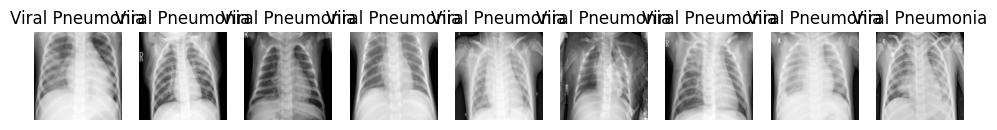

In [8]:
save_dir = r"../reports"
os.makedirs(save_dir, exist_ok=True)

plt.figure(figsize=(12,4))
for i in range(9):
    plt.subplot(1,9,i+1)
    plt.imshow(X_cnn[i].squeeze(), cmap='gray')
    plt.title(le.classes_[np.argmax(y_cnn[i])])
    plt.axis('off')
    # Sauvegarde de chaque image individuellement
    plt.savefig(os.path.join(save_dir, f"sample_image_{i}.png"))

plt.show()



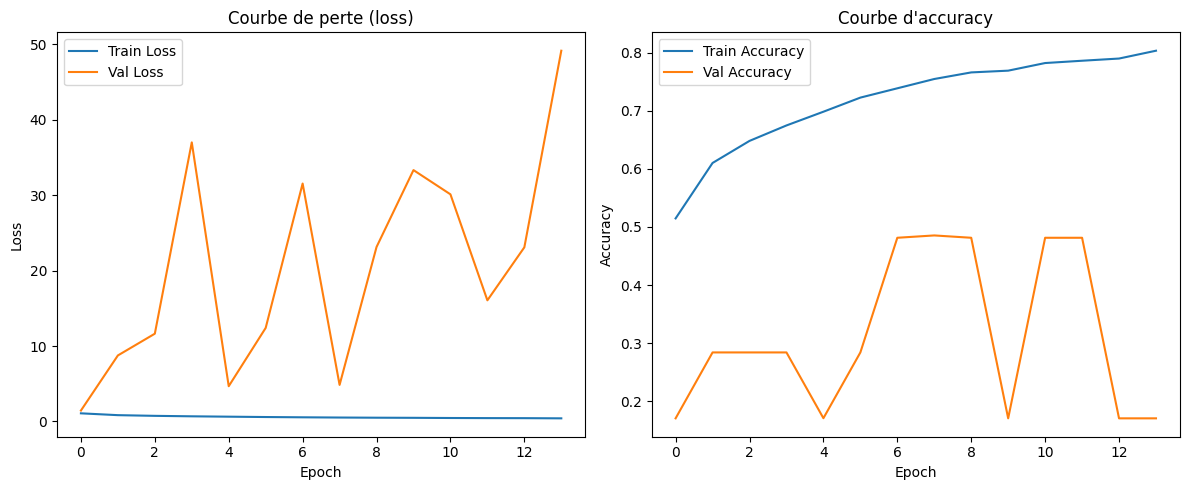

In [9]:
# ------------------------------------------------
# 🔹 Analyse des courbes de perte et d'accuracy
# ------------------------------------------------
plt.figure(figsize=(12,5))

# Courbes de loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Courbe de perte (loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Courbes d'accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Courbe d\'accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "loss_accuracy_curves.png"))
plt.show()